# 3.6 — Multi-Task Learning: Joint Regression + Classification

Jointly predict **`health_gain`** (regression) and **`NO_Benefit`** (binary classification, `health_gain < 7`)
using a single **two-head MLP** (PyTorch) with a shared feature trunk.

**Hypothesis:** A shared representation allows the classification signal to regularise the regression
head and vice versa, potentially improving both tasks simultaneously.

**How the two tasks help each other in this notebook:** `NO_Benefit` is derived from `health_gain` using a clinical threshold (`health_gain < 7`).
That means both heads are learning the same underlying patient outcome at two levels:
- the **regression head** learns the exact size of improvement,
- the **classification head** learns whether that improvement is clinically insufficient.

The shared trunk can therefore learn features that are useful for both fine-grained prediction and threshold-based risk stratification.
In principle, the classification task can sharpen the model around the decision boundary near 7, while the regression task can preserve the full ordering and distance between patients above and below that cutoff.
If this shared representation is useful, both tasks should improve; if the objectives compete or one task adds little new information, multitask learning may not outperform strong single-task baselines.

| | |
|---|---|
| **Data** | `./data/interim/2.0-preprocessing.parquet` (same pipeline as 3.5) |
| **Null handling** | `drop_nulls()` — listwise deletion |
| **Split** | Year-based (last year = test) |
| **Model** | Two-head PyTorch MLP — shared trunk → regression head + classification head |
| **Loss** | `alpha * MSE(health_gain) + (1-alpha) * BCE(NO_Benefit)` |
| **HPO** | Optuna 25 trials (TPE sampler) |
| **Regression baseline** | CatBoost RMSE = **8.0186**, R² = 0.2952 (notebook 3.2) |
| **Classification baseline** | CatBoost PR-AUC = 0.355, ROC-AUC = 0.724 (notebook 3.1) |

## 0. Imports & Setup

In [1]:
import subprocess, sys
_packages = [
    'polars', 'scikit-learn', 'catboost', 'joblib',
    'matplotlib', 'seaborn', 'numpy', 'pandas', 'optuna', 'torch',
]
for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
print('All dependencies installed.')

All dependencies installed.


In [2]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

import polars as pl
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error, r2_score,
    roc_auc_score, average_precision_score,
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print(f'PyTorch : {torch.__version__}')

PyTorch : 2.11.0+cpu


In [3]:
# ── Constants & results cache ────────────────────────────────────────────────
BASELINE_RMSE  = 8.0186   # 3.2 CatBoost, Pipeline1
BASELINE_R2    = 0.2952
BASELINE_PRAUC = 0.355    # 3.1 CatBoost classification (Pipeline1)
N_TRIALS       = 25       # lighter budget: PyTorch training is slower
RANDOM_STATE   = 42

RESULTS_CACHE = Path('./models/3.4-improvement_cache.joblib')
RESULTS_CACHE.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_CACHE.exists():
    improvement_results = joblib.load(RESULTS_CACHE)
    print(f'Loaded cache ({len(improvement_results)} entries): {list(improvement_results.keys())}')
else:
    improvement_results = {}

def _record(label: str, test_rmse: float, test_r2: float, notes: str = '', extra: dict = None):
    improvement_results[label] = {
        'test_rmse': test_rmse, 'test_r2': test_r2,
        'notes': notes, 'delta_rmse': BASELINE_RMSE - test_rmse,
        **(extra or {}),
    }
    joblib.dump(improvement_results, RESULTS_CACHE)
    print(f'  [{label}]  RMSE={test_rmse:.4f}  R²={test_r2:.4f}  Δ={BASELINE_RMSE-test_rmse:+.4f}')

print(f'Baseline: RMSE={BASELINE_RMSE}  R²={BASELINE_R2}')

Loaded cache (8 entries): ['Yeo-Johnson Target Transform', 'RTM Features (pre_op_total + pre_op_deviation + potential_gain)', 'Polynomial Interactions (top-5 SHAP)', 'Target Encoding (OOF, smoothing=30)', 'Subgroup Models (pre-op quartiles)', 'MLP (QuantileTransformer, 80 trials)', 'Optuna Weighted Blend', 'Reframe: Predict Post-Op Score']
Baseline: RMSE=8.0186  R²=0.2952


## 1. Data Preparation

Same pipeline as notebook 3.5: `2.0-preprocessing.parquet`, drop post-op columns and nulls, year-based split. `health_gain` is computed from post-op score minus the sum of the 12 individual pre-op OKS questions.

In [4]:
# ── Load from 2.0-preprocessing.parquet (same as 3.5) ────────────────────────
df_raw = pl.read_parquet('./data/interim/2.0-preprocessing.parquet')
print(f'Raw shape: {df_raw.shape}')

TARGET_POSTOP = 'Knee Replacement Post-Op Q Score'
assert TARGET_POSTOP in df_raw.columns, 'Target column not found!'

# Drop all post-op cols except the target + redundant admin cols
post_op_cols   = [c for c in df_raw.columns if 'Post-Op' in c and c != TARGET_POSTOP]
predicted_cols = [c for c in df_raw.columns if 'Predicted' in c]
admin_cols = [
    'Knee Replacement Pre-Op Q Score',
    'Pre-Op Q EQ5D Index Profile', 'Pre-Op Q EQ5D Index',
    'Provider Code', 'Procedure', 'CSVYear',
    'Pre-Op Q Assisted By', 'Pre-Op Q EQ VAS',
]
drop_exist = [c for c in set(admin_cols + post_op_cols + predicted_cols) if c in df_raw.columns]
df_mt = df_raw.drop(drop_exist)

# Listwise deletion
n_before = df_mt.shape[0]
df_mt    = df_mt.drop_nulls()
print(f'Rows: {n_before:,} → {df_mt.shape[0]:,}  (removed {n_before - df_mt.shape[0]:,} with nulls)')
print(f'Columns kept ({len(df_mt.columns)}): {df_mt.columns}')

Raw shape: (139236, 61)
Rows: 139,236 → 112,652  (removed 26,584 with nulls)
Columns kept (43): ['Revision Flag', 'Year', 'Age Band', 'Gender', 'Pre-Op Q Assisted', 'Pre-Op Q Symptom Period', 'Pre-Op Q Previous Surgery', 'Pre-Op Q Living Arrangements_1', 'Pre-Op Q Living Arrangements_2', 'Pre-Op Q Living Arrangements_3', 'Pre-Op Q Living Arrangements_4', 'Pre-Op Q Living Arrangements_null', 'Pre-Op Q Disability', 'Heart Disease', 'High Bp', 'Stroke', 'Circulation', 'Lung Disease', 'Diabetes', 'Kidney Disease', 'Nervous System', 'Liver Disease', 'Cancer', 'Depression', 'Arthritis', 'Pre-Op Q Mobility', 'Pre-Op Q Self-Care', 'Pre-Op Q Activity', 'Pre-Op Q Discomfort', 'Pre-Op Q Anxiety', 'Knee Replacement Pre-Op Q Pain', 'Knee Replacement Pre-Op Q Night Pain', 'Knee Replacement Pre-Op Q Washing', 'Knee Replacement Pre-Op Q Transport', 'Knee Replacement Pre-Op Q Walking', 'Knee Replacement Pre-Op Q Standing', 'Knee Replacement Pre-Op Q Limping', 'Knee Replacement Pre-Op Q Kneeling', 'Knee

In [5]:
# ── Year-based split ─────────────────────────────────────────────────────────
YEAR_COL  = 'Year'
test_year = int(df_mt[YEAR_COL].unique().sort()[-1])
df_mt_train = df_mt.filter(pl.col(YEAR_COL) < test_year)
df_mt_test  = df_mt.filter(pl.col(YEAR_COL) == test_year)
print(f'Train: {df_mt_train.shape[0]:,}  Test: {df_mt_test.shape[0]:,}  (test year: {test_year})')

# ── Compute targets ───────────────────────────────────────────────────────────
# Pre-op total = sum of the 12 individual OKS question scores
OKS_COLS_MT = [c for c in df_mt_train.columns if 'Knee Replacement Pre-Op Q' in c]
feat_mt     = [c for c in df_mt_train.columns if c not in [TARGET_POSTOP, YEAR_COL]]

pre_op_tr   = df_mt_train.select(OKS_COLS_MT).to_numpy().sum(axis=1)
pre_op_te   = df_mt_test.select(OKS_COLS_MT).to_numpy().sum(axis=1)

y_hg_tr = (df_mt_train[TARGET_POSTOP].to_numpy() - pre_op_tr).astype(np.float32)
y_hg_te = (df_mt_test[TARGET_POSTOP].to_numpy()  - pre_op_te).astype(np.float32)

# NO_Benefit: 1 if health_gain < 7 (clinical threshold)
y_nb_tr = (y_hg_tr < 7).astype(np.float32)
y_nb_te = (y_hg_te < 7).astype(np.float32)

X_mt_tr = df_mt_train.select(feat_mt).to_pandas()
X_mt_te = df_mt_test.select(feat_mt).to_pandas()

print(f'health_gain  mean={y_hg_tr.mean():.2f}  std={y_hg_tr.std():.2f}  range=[{y_hg_tr.min():.0f},{y_hg_tr.max():.0f}]')
print(f'NO_Benefit prevalence  train: {y_nb_tr.mean():.1%}   test: {y_nb_te.mean():.1%}')

Train: 75,774  Test: 36,878  (test year: 3)
health_gain  mean=16.86  std=9.76  range=[-37,47]
NO_Benefit prevalence  train: 14.7%   test: 13.9%


In [6]:
# ── Preprocess features ───────────────────────────────────────────────────────
# X_mt_tr is a pandas DataFrame — use pandas dtype detection
num_mt = X_mt_tr.select_dtypes(include=['number']).columns.tolist()
cat_mt = X_mt_tr.select_dtypes(exclude=['number']).columns.tolist()
print(f'Numeric: {len(num_mt)}  Categorical: {len(cat_mt)}')

num_pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
])
transformers = [('num', num_pipe, num_mt)]
if cat_mt:
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='constant', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    transformers.append(('cat', cat_pipe, cat_mt))

pre_mt = ColumnTransformer(transformers, remainder='drop')
X_mt_tr_prep = pre_mt.fit_transform(X_mt_tr).astype(np.float32)
X_mt_te_prep = pre_mt.transform(X_mt_te).astype(np.float32)
print(f'Feature matrix: train={X_mt_tr_prep.shape}  test={X_mt_te_prep.shape}')

Numeric: 41  Categorical: 0
Feature matrix: train=(75774, 41)  test=(36878, 41)


## 2. Two-Head MLP with PyTorch

A shared trunk branches into:
- **Regression head** → predicts `health_gain` directly (MSE loss)
- **Classification head** → predicts `NO_Benefit` logit (BCE loss)

### Why this can help
Both heads update the same shared layers before splitting into separate outputs. During backpropagation, the regression loss pushes the shared trunk to encode information that helps estimate the exact health gain, while the classification loss pushes the same trunk to encode information that separates patients below and above the clinical threshold.

In this experiment, the classification target is a thresholded version of the regression target, so the auxiliary task acts like an extra training signal rather than a completely different label. That can help the network learn a representation that is both numerically accurate and clinically sensitive around the `health_gain = 7` boundary.

### Why it may not help
Because `NO_Benefit` is derived from `health_gain`, the second task does not add fully independent information. If the classification signal is mostly redundant, or if the two losses pull the shared layers in slightly different directions, the joint model can underperform simpler single-task models even though the idea is theoretically sound.

Combined loss: `alpha * MSE + (1-alpha) * BCE`. Optuna searches architecture and training hyperparameters over 25 trials using a 15% chronological hold-out from the training set for validation.

In [7]:
# ── Two-Head MLP definition (PyTorch) ────────────────────────────────────────
class MultiTaskMLP(nn.Module):
    """
    Shared trunk: Linear -> BatchNorm -> ReLU -> Dropout (x n_layers)
    Regression head : predicts health_gain (MSE loss)
    Classification head : predicts NO_Benefit logit (BCE loss)
    """
    def __init__(self, input_dim: int, hidden_dim: int, n_layers: int, dropout: float):
        super().__init__()
        layers = []
        prev = input_dim
        for _ in range(n_layers):
            layers += [nn.Linear(prev, hidden_dim), nn.BatchNorm1d(hidden_dim),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = hidden_dim
        self.trunk    = nn.Sequential(*layers)
        self.reg_head = nn.Linear(prev, 1)
        self.cls_head = nn.Linear(prev, 1)

    def forward(self, x):
        h = self.trunk(x)
        return self.reg_head(h).squeeze(-1), self.cls_head(h).squeeze(-1)


def train_multitask(X_tr, y_reg, y_cls, *,
                    hidden_dim, n_layers, dropout, lr, alpha, epochs, batch_size):
    ds  = TensorDataset(torch.from_numpy(X_tr),
                        torch.from_numpy(y_reg),
                        torch.from_numpy(y_cls))
    dl  = DataLoader(ds, batch_size=batch_size, shuffle=True)
    mdl = MultiTaskMLP(X_tr.shape[1], hidden_dim, n_layers, dropout)
    opt = optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        mdl.train()
        for xb, yr, yc in dl:
            pr, pc = mdl(xb)
            loss   = alpha * mse(pr, yr) + (1.0 - alpha) * bce(pc, yc)
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
    return mdl


def predict_multitask(mdl, X):
    mdl.eval()
    with torch.no_grad():
        pr, pc = mdl(torch.from_numpy(X))
    return pr.numpy(), torch.sigmoid(pc).numpy()


print('MultiTaskMLP defined.')

MultiTaskMLP defined.


In [8]:
# ── Optuna: tune hidden_dim, n_layers, dropout, lr, alpha, epochs ────────────
import time

# Hold out last 15% of training rows as HPO validation (chronological)
val_n = int(len(X_mt_tr_prep) * 0.15)
X_hpo_tr,  X_hpo_val   = X_mt_tr_prep[:-val_n], X_mt_tr_prep[-val_n:]
y_hg_hpo_tr, y_hg_hpo_val = y_hg_tr[:-val_n],  y_hg_tr[-val_n:]
y_nb_hpo_tr, y_nb_hpo_val = y_nb_tr[:-val_n],  y_nb_tr[-val_n:]

_trial_times_mt = []

def objective_mt(trial):
    t0     = time.time()
    params = dict(
        hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256]),
        n_layers   = trial.suggest_int('n_layers', 2, 4),
        dropout    = trial.suggest_float('dropout', 0.1, 0.4),
        lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True),
        alpha      = trial.suggest_float('alpha', 0.5, 0.9),
        epochs     = trial.suggest_int('epochs', 40, 120, step=20),
        batch_size = trial.suggest_categorical('batch_size', [512, 1024]),
    )
    torch.manual_seed(RANDOM_STATE)
    mdl      = train_multitask(X_hpo_tr, y_hg_hpo_tr, y_nb_hpo_tr, **params)
    pred_hg, _ = predict_multitask(mdl, X_hpo_val)
    val_rmse = float(np.sqrt(mean_squared_error(y_hg_hpo_val, pred_hg)))
    elapsed  = time.time() - t0
    _trial_times_mt.append(elapsed)
    n   = len(_trial_times_mt)
    eta = (sum(_trial_times_mt) / n) * (N_TRIALS - n)
    print(f'  Trial {n:>2}/{N_TRIALS}  val_RMSE={val_rmse:.4f}  ETA={eta:.0f}s', end='\r')
    return val_rmse

torch.manual_seed(RANDOM_STATE)
study_mt = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
study_mt.optimize(objective_mt, n_trials=N_TRIALS, show_progress_bar=False)
print(f'\nBest val RMSE : {study_mt.best_value:.4f}')
print(f'Best params   : {study_mt.best_params}')

  Trial 25/25  val_RMSE=8.4082  ETA=0s0ss
Best val RMSE : 8.3967
Best params   : {'hidden_dim': 128, 'n_layers': 3, 'dropout': 0.23143905024734038, 'lr': 0.00028755903712453744, 'alpha': 0.6987586652315626, 'epochs': 100, 'batch_size': 1024}


In [9]:
# ── Retrain on full training set, evaluate on test ───────────────────────────
best = study_mt.best_params
torch.manual_seed(RANDOM_STATE)
final_model = train_multitask(
    X_mt_tr_prep, y_hg_tr, y_nb_tr,
    hidden_dim = best['hidden_dim'],
    n_layers   = best['n_layers'],
    dropout    = best['dropout'],
    lr         = best['lr'],
    alpha      = best['alpha'],
    epochs     = best['epochs'] + 50,   # extra epochs on full training data
    batch_size = best['batch_size'],
)

pred_hg_te, pred_nb_prob_te = predict_multitask(final_model, X_mt_te_prep)

test_rmse_mt = float(np.sqrt(mean_squared_error(y_hg_te, pred_hg_te)))
test_r2_mt   = float(r2_score(y_hg_te, pred_hg_te))
test_roc_mt  = float(roc_auc_score(y_nb_te, pred_nb_prob_te))
test_pr_mt   = float(average_precision_score(y_nb_te, pred_nb_prob_te))

print(f'Health Gain RMSE   : {test_rmse_mt:.4f}  (baseline={BASELINE_RMSE:.4f}  delta={BASELINE_RMSE-test_rmse_mt:+.4f})')
print(f'Health Gain R²      : {test_r2_mt:.4f}')
print(f'NO_Benefit ROC-AUC : {test_roc_mt:.4f}  (3.1 baseline=0.724)')
print(f'NO_Benefit PR-AUC  : {test_pr_mt:.4f}  (3.1 baseline={BASELINE_PRAUC:.4f}  delta={test_pr_mt-BASELINE_PRAUC:+.4f})')

_record(
    'Multi-Task MLP (Regression + Classification)',
    test_rmse = test_rmse_mt,
    test_r2   = test_r2_mt,
    notes     = f'Two-head PyTorch MLP; alpha={best["alpha"]:.2f}; hidden={best["hidden_dim"]}x{best["n_layers"]}; epochs={best["epochs"]+50}',
    extra     = {'roc_auc': test_roc_mt, 'pr_auc': test_pr_mt},
)

Health Gain RMSE   : 8.1907  (baseline=8.0186  delta=-0.1721)
Health Gain R²      : 0.2968
NO_Benefit ROC-AUC : 0.7129  (3.1 baseline=0.724)
NO_Benefit PR-AUC  : 0.3427  (3.1 baseline=0.3550  delta=-0.0123)
  [Multi-Task MLP (Regression + Classification)]  RMSE=8.1907  R²=0.2968  Δ=-0.1721


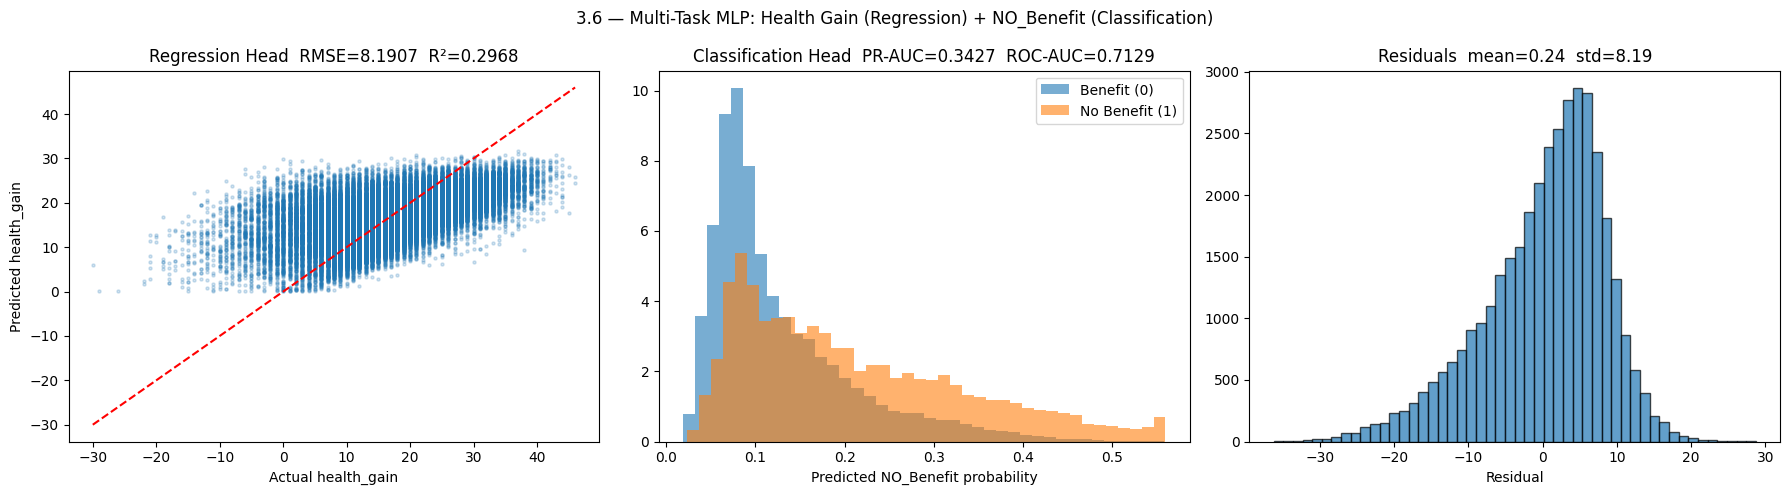

Regression vs 3.2 baseline  : RMSE 8.1907 vs 8.0186  (delta=-0.1721)
Classification vs 3.1 baseline: PR-AUC 0.3427 vs 0.3550  (delta=-0.0123)


In [10]:
# ── Diagnostic plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3.6 — Multi-Task MLP: Health Gain (Regression) + NO_Benefit (Classification)', fontsize=12)

# (1) Regression: actual vs predicted
axes[0].scatter(y_hg_te, pred_hg_te, alpha=0.2, s=5)
lims = [min(y_hg_te.min(), pred_hg_te.min()), max(y_hg_te.max(), pred_hg_te.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual health_gain')
axes[0].set_ylabel('Predicted health_gain')
axes[0].set_title(f'Regression Head  RMSE={test_rmse_mt:.4f}  R²={test_r2_mt:.4f}')

# (2) Classification: probability distributions by class
axes[1].hist(pred_nb_prob_te[y_nb_te == 0], bins=40, alpha=0.6, label='Benefit (0)', density=True)
axes[1].hist(pred_nb_prob_te[y_nb_te == 1], bins=40, alpha=0.6, label='No Benefit (1)', density=True)
axes[1].set_xlabel('Predicted NO_Benefit probability')
axes[1].set_title(f'Classification Head  PR-AUC={test_pr_mt:.4f}  ROC-AUC={test_roc_mt:.4f}')
axes[1].legend()

# (3) Residuals
resid = y_hg_te - pred_hg_te
axes[2].hist(resid, bins=50, edgecolor='k', alpha=0.7)
axes[2].set_title(f'Residuals  mean={resid.mean():.2f}  std={resid.std():.2f}')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()
print(f'Regression vs 3.2 baseline  : RMSE {test_rmse_mt:.4f} vs {BASELINE_RMSE:.4f}  (delta={BASELINE_RMSE-test_rmse_mt:+.4f})')
print(f'Classification vs 3.1 baseline: PR-AUC {test_pr_mt:.4f} vs {BASELINE_PRAUC:.4f}  (delta={test_pr_mt-BASELINE_PRAUC:+.4f})')